In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage
from pathlib import Path
from sklearn.decomposition import PCA

In [4]:
repo_root = Path(__file__).resolve().parents[1] if "__file__" in globals() else Path.cwd().parents[0]
base_path = repo_root / "data" / "averaged"
print("Base path resolved to:", base_path)
files = list(base_path.glob("**/*_inavg.csv"))
if not files:
    raise FileNotFoundError(f"No *_inavg.csv files found under {base_path}")

# ---- Load participant data ---- #
participant_dfs = {}
for file in files:
    name = file.parent.name
    df = pd.read_csv(file)
    participant_dfs[name] = df

# ---- Build RT matrix ---- #
rt_matrix = []
participant_names = []

for name, df in participant_dfs.items():
    rt_col = [col for col in df.columns if col.lower() != "gap"][0]
    rt_values = df[rt_col].values.squeeze()  # ensure 1D
    rt_matrix.append(rt_values)
    participant_names.append(name + "I")

rt_matrix = np.vstack(rt_matrix) 

print("RT matrix shape:", rt_matrix.shape)

Base path resolved to: /Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged
RT matrix shape: (9, 46)



Explained variance ratio: [0.84107251 0.04628434]


/var/folders/3q/7y_0d44d3d17xy40wq2ppmww0000gn/T/ipykernel_7048/3574124981.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(pca_df["PC1"][i] + 0.01, pca_df["PC2"][i], name, fontsize=9)


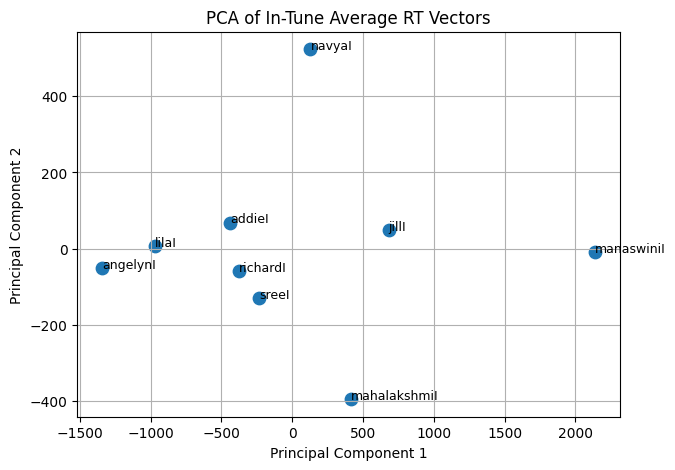

In [5]:
# ---- PCA ---- #
pca = PCA(n_components=2)
pca_result = pca.fit_transform(rt_matrix)
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"], index=participant_names)
print("\nExplained variance ratio:", pca.explained_variance_ratio_)

# plot pca
plt.figure(figsize=(7, 5))
plt.scatter(pca_df["PC1"], pca_df["PC2"], s=80)
for i, name in enumerate(participant_names):
    plt.text(pca_df["PC1"][i] + 0.01, pca_df["PC2"][i], name, fontsize=9)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of In-Tune Average RT Vectors")
plt.grid(True)
plt.show()


Explained variance ratio: [0.84107251 0.04628434 0.03610115]
Total variance explained: 0.92345800938595


/var/folders/3q/7y_0d44d3d17xy40wq2ppmww0000gn/T/ipykernel_7048/4076899279.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(pca_df["PC1"][i], pca_df["PC2"][i], pca_df["PC3"][i], name, fontsize=9)


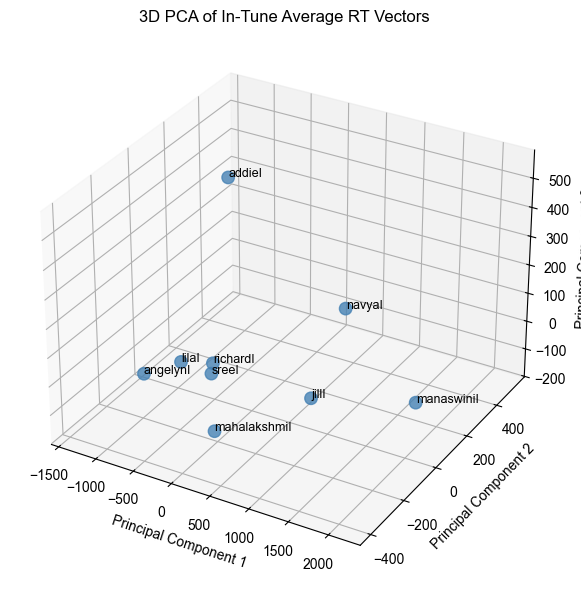

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection

# ---- PCA (3D) ---- #
pca = PCA(n_components=3)
pca_result = pca.fit_transform(rt_matrix)
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2", "PC3"], index=participant_names)

print("\nExplained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

# ---- 3D Plot ---- #
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(pca_df["PC1"], pca_df["PC2"], pca_df["PC3"], s=80, c="steelblue", alpha=0.8)

# Label each participant
for i, name in enumerate(participant_names):
    ax.text(pca_df["PC1"][i], pca_df["PC2"][i], pca_df["PC3"][i], name, fontsize=9)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D PCA of In-Tune Average RT Vectors")
plt.tight_layout()
plt.show()

In [9]:
repo_root = Path(__file__).resolve().parents[1] if "__file__" in globals() else Path.cwd().parents[0]
base_path = repo_root / "data" / "averaged"
print("Base path resolved to:", base_path)
files = list(base_path.glob("**/*_outavg.csv"))
if not files:
    raise FileNotFoundError(f"No *_inavg.csv files found under {base_path}")

# ---- Load participant data ---- #
participant_dfs = {}
for file in files:
    name = file.parent.name
    df = pd.read_csv(file)
    participant_dfs[name] = df

# ---- Build RT matrix ---- #
rt_matrix = []
participant_names = []

for name, df in participant_dfs.items():
    rt_col = [col for col in df.columns if col.lower() != "gap"][0]
    rt_values = df[rt_col].values.squeeze()  # ensure 1D
    rt_matrix.append(rt_values)
    participant_names.append(name + "I")

rt_matrix = np.vstack(rt_matrix) 

print("RT matrix shape:", rt_matrix.shape)

Base path resolved to: /Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged
RT matrix shape: (9, 46)



Explained variance ratio: [0.8091302  0.05015377]


/var/folders/3q/7y_0d44d3d17xy40wq2ppmww0000gn/T/ipykernel_7048/1633948503.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(pca_df["PC1"][i] + 0.01, pca_df["PC2"][i], name, fontsize=9)


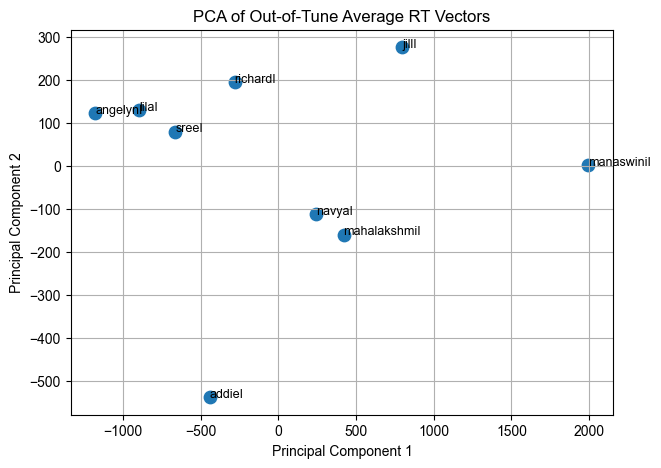

In [11]:
# ---- PCA ---- #
pca = PCA(n_components=2)
pca_result = pca.fit_transform(rt_matrix)
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"], index=participant_names)
print("\nExplained variance ratio:", pca.explained_variance_ratio_)

# plot pca
plt.figure(figsize=(7, 5))
plt.scatter(pca_df["PC1"], pca_df["PC2"], s=80)
for i, name in enumerate(participant_names):
    plt.text(pca_df["PC1"][i] + 0.01, pca_df["PC2"][i], name, fontsize=9)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Out-of-Tune Average RT Vectors")
plt.grid(True)
plt.show()


Explained variance ratio: [0.8091302  0.05015377 0.04496081]
Total variance explained: 0.9042447816146916


/var/folders/3q/7y_0d44d3d17xy40wq2ppmww0000gn/T/ipykernel_7048/1862335516.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(pca_df["PC1"][i], pca_df["PC2"][i], pca_df["PC3"][i], name, fontsize=9)


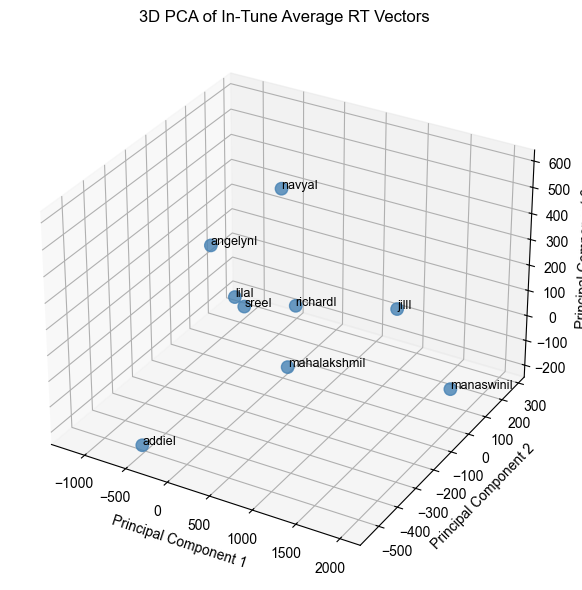

In [12]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection

# ---- PCA (3D) ---- #
pca = PCA(n_components=3)
pca_result = pca.fit_transform(rt_matrix)
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2", "PC3"], index=participant_names)

print("\nExplained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

# ---- 3D Plot ---- #
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(pca_df["PC1"], pca_df["PC2"], pca_df["PC3"], s=80, c="steelblue", alpha=0.8)

# Label each participant
for i, name in enumerate(participant_names):
    ax.text(pca_df["PC1"][i], pca_df["PC2"][i], pca_df["PC3"][i], name, fontsize=9)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D PCA of In-Tune Average RT Vectors")
plt.tight_layout()
plt.show()